In [11]:
! pip install tensorflow tensorflow_hub

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 18.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from utils.video_tools import get_video_files
from scripts.parsers import parse_sequences as parse_sequence_info

file_path = 'gait3d\\ListOfSequences.txt'
sequences = parse_sequence_info(file_path)

In [13]:
sequences.keys()

dict_keys(['p1s1', 'p1s2', 'p1s3', 'p1s4', 'p2s1', 'p2s2', 'p2s3', 'p2s4', 'p3s1', 'p3s2', 'p3s3', 'p3s4', 'p4s1', 'p4s2', 'p4s3', 'p4s4', 'p5s1', 'p5s2', 'p5s3', 'p5s4', 'p6s1', 'p6s2', 'p6s3', 'p6s4', 'p7s1', 'p7s2', 'p7s3', 'p7s4', 'p8s1', 'p8s2', 'p8s3', 'p8s4', 'p9s1', 'p9s2', 'p9s3', 'p9s4', 'p10s1', 'p10s2', 'p10s3', 'p10s4', 'p11s1', 'p11s2', 'p11s3', 'p11s4', 'p12s1', 'p12s2', 'p12s3', 'p12s4', 'p13s1', 'p13s2', 'p13s3', 'p13s4', 'p14s1', 'p14s2', 'p14s3', 'p14s4', 'p15s1', 'p15s2', 'p15s3', 'p15s4', 'p16s1', 'p16s2', 'p16s3', 'p16s4', 'p17s1', 'p17s2', 'p17s3', 'p17s4', 'p18s1', 'p18s2', 'p18s3', 'p18s4', 'p19s1', 'p19s2', 'p19s3', 'p19s4', 'p20s1', 'p20s2', 'p20s3', 'p20s4', 'p21s1', 'p21s2', 'p21s3', 'p21s4', 'p22s1', 'p22s2', 'p22s3', 'p22s4', 'p23s1', 'p23s2', 'p23s3', 'p23s4', 'p24s1', 'p24s2', 'p24s3', 'p24s4', 'p25s1', 'p25s2', 'p25s3', 'p25s4', 'p26s1', 'p26s2', 'p26s3', 'p26s4', 'p26s5', 'p26s6', 'p26s7', 'p26s8', 'p26s9', 'p26s10', 'p27s1', 'p27s2', 'p27s3', 'p27s4'

In [39]:
video_files = get_video_files('p28s9')
video_files

['./gait3d/Sequences/p28s9/Images/c1_0160.avi',
 './gait3d/Sequences/p28s9/Images/c2_0160.avi',
 './gait3d/Sequences/p28s9/Images/c3_0160.avi',
 './gait3d/Sequences/p28s9/Images/c4_0160.avi']

[[0.2550961  0.10703335 0.2093639 ]
 [0.2480202  0.09839053 0.1911759 ]
 [0.24885803 0.10734551 0.24118319]
 [0.25134343 0.0775771  0.3799868 ]
 [0.25265774 0.10301391 0.413135  ]
 [0.2973228  0.06522383 0.5048355 ]
 [0.3008546  0.09996714 0.58354104]
 [0.37828523 0.0725507  0.21121219]
 [0.38863203 0.09800857 0.409544  ]
 [0.4266928  0.10141556 0.20459685]
 [0.43074104 0.11536538 0.25339323]
 [0.42354614 0.07700299 0.35886064]
 [0.42869163 0.09774309 0.41895986]
 [0.53248525 0.09669735 0.18060036]
 [0.5603789  0.10467049 0.36246765]
 [0.6859799  0.10076411 0.23978028]
 [0.6872193  0.09938996 0.36690015]]
[[0.2550961  0.10703335]
 [0.2480202  0.09839053]
 [0.24885803 0.10734551]
 [0.25134343 0.0775771 ]
 [0.25265774 0.10301391]
 [0.2973228  0.06522383]
 [0.3008546  0.09996714]
 [0.37828523 0.0725507 ]
 [0.38863203 0.09800857]
 [0.4266928  0.10141556]
 [0.43074104 0.11536538]
 [0.42354614 0.07700299]
 [0.42869163 0.09774309]
 [0.53248525 0.09669735]
 [0.5603789  0.10467049]
 [0.6859799 

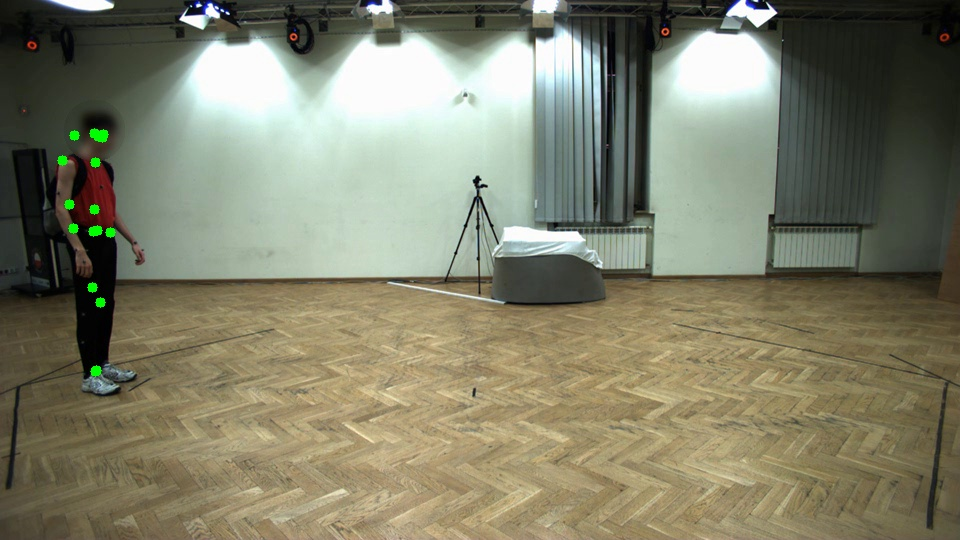

In [62]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
from IPython.display import display, Image, clear_output

CONFIDENCE_THRESHOLD = 0.0

# model = hub.load("https://tfhub.dev/google/movenet/singlepose/lightning/4")
model = hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
movenet = model.signatures['serving_default']

cap = cv2.VideoCapture(video_files[2])

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # input_size = 192
        input_size = 256
        img_resized = cv2.resize(frame, (input_size, input_size))
        input_img = tf.cast(tf.expand_dims(img_resized, axis=0), dtype=tf.int32)

        outputs = movenet(input_img)
        keypoints = outputs['output_0'].numpy()[0, 0, :, :]
        print(keypoints)
        print(keypoints[:,:2])
        print([[pos[1], pos[0]] for pos in keypoints])

        h, w, _ = frame.shape
        for kp in keypoints:
            y, x, conf = kp
            if conf > CONFIDENCE_THRESHOLD:
                cv2.circle(frame, (int(x * w), int(y * h)), 5, (0, 255, 0), -1)

        _, encoded_img = cv2.imencode('.jpg', frame)
        
        # clear_output(wait=True)
        display(Image(data=encoded_img))
        break
        
finally:
    cap.release()

In [42]:
video_path = './gait3d/Sequences/p28s9/Images/c1_0160.avi'
video_path.split('/')[-1].split('_')[0]

'c1'

In [65]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import json
import numpy as np
from IPython.display import display, Image, clear_output
from typing import Literal, Sequence
from utils.video_tools import get_video_files


def prepare_movenet_dataset(
    movenet_type:Literal['thunder', 'lightning'], 
    sequences_keys: Sequence[str],
):
    dataset = {}
    dataset_with_confidence = {}
    
    if movenet_type == 'thunder':
        model = hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
        input_size = 256
    else:
        model = hub.load("https://tfhub.dev/google/movenet/singlepose/lightning/4")
        input_size = 192
        
    movenet = model.signatures['serving_default']
    
    for sequence_key in sequences_keys:
        print(f"| {sequence_key}", end=" ")
        dataset[sequence_key] = {f'c{i}': [] for i in range(1, 5)}
        dataset_with_confidence[sequence_key] = {f'c{i}': [] for i in range(1, 5)}

        video_files = get_video_files(sequence_key)
        for video_path in video_files:
            camera = video_path.split('/')[-1].split('_')[0]
            print(camera, end=" ")
            cap = cv2.VideoCapture(video_path)

            try:
                while True:
                    ret, frame = cap.read()
                    if not ret:
                        break

                    img_resized = cv2.resize(frame, (input_size, input_size))
                    input_img = tf.cast(tf.expand_dims(img_resized, axis=0), dtype=tf.int32)
            
                    outputs = movenet(input_img)
                    keypoints = outputs['output_0'].numpy()[0, 0, :, :]

                    dataset[sequence_key][camera].append([[pos[1], pos[0]] for pos in keypoints.tolist()])
                    dataset_with_confidence[sequence_key][camera].append([[pos[1], pos[0], pos[2]] for pos in keypoints.tolist()])
                    
            finally:
                cap.release()

    with open(f"./datasets/movenet/dataset_{movenet_type}.json", "w") as f:
        json.dump(dataset, f, indent=4)
        
    with open(f"./datasets/movenet/dataset_with_confidence_{movenet_type}.json", "w") as f:
        json.dump(dataset_with_confidence, f, indent=4)

In [66]:
prepare_movenet_dataset(movenet_type='lightning', sequences_keys=['p1s1'])

| p1s1 c1 c2 c3 c4 

In [67]:
prepare_movenet_dataset(
    movenet_type='lightning', 
    sequences_keys=sequences.keys()
)

| p1s1 c1 c2 c3 c4 | p1s2 c1 c2 c3 c4 | p1s3 c1 c2 c3 c4 | p1s4 c1 c2 c3 c4 | p2s1 c1 c2 c3 c4 | p2s2 c1 c2 c3 c4 | p2s3 c1 c2 c3 c4 | p2s4 c1 c2 c3 c4 | p3s1 c1 c2 c3 c4 | p3s2 c1 c2 c3 c4 | p3s3 c1 c2 c3 c4 | p3s4 c1 c2 c3 c4 | p4s1 c1 c2 c3 c4 | p4s2 c1 c2 c3 c4 | p4s3 c1 c2 c3 c4 | p4s4 c1 c2 c3 c4 | p5s1 c1 c2 c3 c4 | p5s2 c1 c2 c3 c4 | p5s3 c1 c2 c3 c4 | p5s4 c1 c2 c3 c4 | p6s1 c1 c2 c3 c4 | p6s2 c1 c2 c3 c4 | p6s3 c1 c2 c3 c4 | p6s4 c1 c2 c3 c4 | p7s1 c1 c2 c3 c4 | p7s2 c1 c2 c3 c4 | p7s3 c1 c2 c3 c4 | p7s4 c1 c2 c3 c4 | p8s1 c1 c2 c3 c4 | p8s2 c1 c2 c3 c4 | p8s3 c1 c2 c3 c4 | p8s4 c1 c2 c3 c4 | p9s1 c1 c2 c3 c4 | p9s2 c1 c2 c3 c4 | p9s3 c1 c2 c3 c4 | p9s4 c1 c2 c3 c4 | p10s1 c1 c2 c3 c4 | p10s2 c1 c2 c3 c4 | p10s3 c1 c2 c3 c4 | p10s4 c1 c2 c3 c4 | p11s1 c1 c2 c3 c4 | p11s2 c1 c2 c3 c4 | p11s3 c1 c2 c3 c4 | p11s4 c1 c2 c3 c4 | p12s1 c1 c2 c3 c4 | p12s2 c1 c2 c3 c4 | p12s3 c1 c2 c3 c4 | p12s4 c1 c2 c3 c4 | p13s1 c1 c2 c3 c4 | p13s2 c1 c2 c3 c4 | p13s3 c1 c2 c3 c4 | p13s4 c1 c2 c3

In [68]:
prepare_movenet_dataset(
    movenet_type='thunder', 
    sequences_keys=sequences.keys()
)

| p1s1 c1 c2 c3 c4 | p1s2 c1 c2 c3 c4 | p1s3 c1 c2 c3 c4 | p1s4 c1 c2 c3 c4 | p2s1 c1 c2 c3 c4 | p2s2 c1 c2 c3 c4 | p2s3 c1 c2 c3 c4 | p2s4 c1 c2 c3 c4 | p3s1 c1 c2 c3 c4 | p3s2 c1 c2 c3 c4 | p3s3 c1 c2 c3 c4 | p3s4 c1 c2 c3 c4 | p4s1 c1 c2 c3 c4 | p4s2 c1 c2 c3 c4 | p4s3 c1 c2 c3 c4 | p4s4 c1 c2 c3 c4 | p5s1 c1 c2 c3 c4 | p5s2 c1 c2 c3 c4 | p5s3 c1 c2 c3 c4 | p5s4 c1 c2 c3 c4 | p6s1 c1 c2 c3 c4 | p6s2 c1 c2 c3 c4 | p6s3 c1 c2 c3 c4 | p6s4 c1 c2 c3 c4 | p7s1 c1 c2 c3 c4 | p7s2 c1 c2 c3 c4 | p7s3 c1 c2 c3 c4 | p7s4 c1 c2 c3 c4 | p8s1 c1 c2 c3 c4 | p8s2 c1 c2 c3 c4 | p8s3 c1 c2 c3 c4 | p8s4 c1 c2 c3 c4 | p9s1 c1 c2 c3 c4 | p9s2 c1 c2 c3 c4 | p9s3 c1 c2 c3 c4 | p9s4 c1 c2 c3 c4 | p10s1 c1 c2 c3 c4 | p10s2 c1 c2 c3 c4 | p10s3 c1 c2 c3 c4 | p10s4 c1 c2 c3 c4 | p11s1 c1 c2 c3 c4 | p11s2 c1 c2 c3 c4 | p11s3 c1 c2 c3 c4 | p11s4 c1 c2 c3 c4 | p12s1 c1 c2 c3 c4 | p12s2 c1 c2 c3 c4 | p12s3 c1 c2 c3 c4 | p12s4 c1 c2 c3 c4 | p13s1 c1 c2 c3 c4 | p13s2 c1 c2 c3 c4 | p13s3 c1 c2 c3 c4 | p13s4 c1 c2 c3